<a href="https://colab.research.google.com/github/kibwale/nipe_macho/blob/main/notebooks/testing_new_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataset Augmentation Using the RDD2020 Road Damage Dataset

## Motivation

Following the analysis of the **Chepalungu pothole dataset**, we observed that although the dataset captured road conditions within the study area, its relatively limited size and geographic scope could restrict the model's ability to generalize to unseen environments.

To improve the diversity of the training data, we investigated the use of an external road damage dataset that could supplement our locally collected images. Rather than replacing the Chepalungu dataset, our objective was to augment it with additional annotated images representing a wider range of road damage types, lighting conditions, weather conditions, road surfaces, and camera viewpoints.

For this purpose, we selected the **RDD2020 (Road Damage Detection 2020)** dataset, a publicly available benchmark developed through an international collaboration for automated road damage detection. The dataset contains thousands of annotated road images collected from multiple countries, making it well suited for improving the robustness and generalization capability of deep learning models.

**RDD2020 Dataset:** https://github.com/sekilab/RoadDamageDetector

In the following sections, we download the dataset, convert its annotations into the YOLO format, verify the generated labels, and prepare the data for integration with the existing Chepalungu dataset prior to model training.

In [1]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


## 1. Environment Setup & Custom Modules

To streamline the analysis, we use our custom framework, **Fynesse** (its  like a utility folder), which provides reusable utilities for dataset preparation and model development.

We begin by cloning the project repository from GitHub. The following cell removes any existing local copy, downloads the latest version of the repository, and adds it to the Python path, making the custom modules available for use throughout the notebook.

In [2]:
# Remove existing repository folder to ensure a clean clone and setup
import shutil
shutil.rmtree("/content/nipe_macho", ignore_errors=True)
# Clone the latest version of the repository from GitHub

!git clone https://github.com/silprosa/nipe_macho.git
import os, subprocess, importlib, sys
sys.path.append("/content/nipe_macho")
from fynesse import access , assess , address

Cloning into 'nipe_macho'...
remote: Enumerating objects: 278, done.
remote: Counting objects: 100% (138/138), done.
remote: Compressing objects: 100% (118/118), done.
remote: Total 278 (delta 90), reused 20 (delta 20), pack-reused 140 (from 2)
Receiving objects: 100% (278/278), 24.31 MiB | 6.69 MiB/s, done.
Resolving deltas: 100% (133/133), done.


In [3]:
from google.colab import userdata
!pip install -q ultralytics
from ultralytics import YOLO
import os
import xml.etree.ElementTree as ET
from pathlib import Path
!pip install roboflow
from roboflow import Roboflow
!pip install -q kaggle
import random
import hashlib

## 2. Loading Datasets

For convenience, we obtain a Kaggle-hosted copy of the **RDD2020** dataset. The following cell authenticates with the Kaggle API using stored credentials and downloads the dataset directly into the Colab environment, where it is automatically extracted for subsequent preprocessing.

In [5]:
os.environ['KAGGLE_KEY'] =userdata.get("kaggleme")
!kaggle datasets download -d ziedkelboussi/rdd2020-dataset -p /content/rdd2020 --unzip

Dataset URL: https://www.kaggle.com/datasets/ziedkelboussi/rdd2020-dataset
License(s): unknown
100% 1.38G/1.38G [00:19<00:00, 76.0MB/s]



As described previously, the Chepalungu dataset is retrieved directly from Roboflow using the project API and downloaded in .txt format for subsequent integration with the RDD2020 dataset

In [6]:
api_key = userdata.get('roboflow_api')
rf = Roboflow(api_key=api_key)
project = rf.workspace("nipemacho").project("chepalungu")
dataset = project.version(1).download("yolov8")

loading Roboflow workspace...
loading Roboflow project...


## 3. Converting the RDD2020 Annotations

The RDD2020 dataset uses XML annotations, which are incompatible with YOLO.

In [7]:
xml_file = next(Path("/content/rdd2020").rglob("*.xml"))
print(xml_file)
tree = ET.parse(xml_file)
root = tree.getroot()
ET.dump(root)

/content/rdd2020/train/Czech/annotations/xmls/Czech_003116.xml
<annotation>
  <folder>images</folder>
  <filename>Czech_003116.jpg</filename>
  <size>
    <depth>3</depth>
    <width>600</width>
    <height>600</height>
  </size>
</annotation>


In [8]:
classes = set()

for xml_file in Path("/content/rdd2020").rglob("*.xml"):
    root = ET.parse(xml_file).getroot()
    for obj in root.findall("object"):
        classes.add(obj.find("name").text)

print(f"Found {len(classes)} classes:")
print(sorted(classes))

Found 10 classes:
['D00', 'D01', 'D0w0', 'D10', 'D11', 'D20', 'D40', 'D43', 'D44', 'D50']



> **Why retain only the D40 class?**  
> The objective of this study is to improve pothole detection, not general road damage detection. Since the Chepalungu dataset contains only potholes, retaining all RDD2020 damage categories (e.g., longitudinal cracks, transverse cracks, alligator cracks) would introduce additional classes that are not present in the original dataset therefore we only retain the  **D40** class


The following cell converts the annotations to the YOLO format, retains only the **D40 (pothole)** class, and generates the corresponding dataset configuration file (`data.yaml`) for training.

In [9]:
DRIVE_ROOT = "/content/rdd2020"
TARGET_CLASSES = ["D40"]  # pothole only, becomes class 0

classes = access.convert_dataset(DRIVE_ROOT, TARGET_CLASSES)
access.write_data_yaml(DRIVE_ROOT, classes)

Found 3 annotation folders
Converted 2829 files in /content/rdd2020/train/Czech
Converted 7706 files in /content/rdd2020/train/India
Converted 10506 files in /content/rdd2020/train/Japan

Total boxes: 5627
Images containing at least one target box: 3074
data.yaml written to /content/rdd2020/data.yaml


### 3.1 Dataset Quality Assessment

After retaining only the **D40 (pothole)** class, many images no longer contain annotations because they originally contained other types of road damage. before proceeding with dataset augmentation and model training, we perform a sanity check to quantify the distribution of annotated and empty images across the training subsets



In [10]:
for country in ["Japan", "Czech", "India"]:
    lbl_dir = Path(f"/content/rdd2020/train/{country}/labels")
    files = list(lbl_dir.glob("*.txt"))
    empty = sum(1 for f in files if f.stat().st_size == 0)
    nonempty = len(files) - empty
    print(f"{country}: {nonempty} with pothole, {empty} empty ({empty/len(files)*100:.1f}% empty)")

Japan: 1390 with pothole, 9116 empty (86.8% empty)
Czech: 154 with pothole, 2675 empty (94.6% empty)
India: 1530 with pothole, 6176 empty (80.1% empty)


This assessment provides an estimate of the available pothole samples and helps identify the proportion of images that would contribute little or no learning signal if included during training. Understanding this distribution informs subsequent preprocessing decisions, such as whether to retain or remove empty-label images prior to model training.

In [11]:
for country in ["Japan", "Czech", "India"]:
    assess.subsample_negatives( DRIVE_ROOT,country,keep_ratio=1.5)

Japan: 1390 positive, 2085 negatives kept, 7031 negatives removed
Czech: 154 positive, 231 negatives kept, 2444 negatives removed
India: 1530 positive, 2295 negatives kept, 3881 negatives removed


### 3.3 Consolidating the Dataset and Creating the Training Split

Following preprocessing, the country-specific subsets are consolidated into a single unified dataset. Images and their corresponding annotations are randomly partitioned into **training (85%)** and **validation (15%)** sets while preserving image-label pairs. To prevent filename collisions between countries, each file is prefixed with its country of origin before being copied into the unified directory structure.

Finally, a new `data.yaml` configuration file is generated to reference the consolidated dataset, preparing it for subsequent model training with YOLO.

In [12]:
DRIVE_ROOT = "/content/rdd2020"
ROBOFLOW_ROOT = dataset.location
FINAL_ROOT = "/content/rdd2020/final"
VAL_RATIO = 0.2
random.seed(42)

# unified output dirs
final_train_img = Path(f"{DRIVE_ROOT}/final/train/images")
final_train_lbl = Path(f"{DRIVE_ROOT}/final/train/labels")
final_val_img = Path(f"{DRIVE_ROOT}/final/val/images")
final_val_lbl = Path(f"{DRIVE_ROOT}/final/val/labels")

for d in [final_train_img, final_train_lbl, final_val_img, final_val_lbl]:
    d.mkdir(parents=True, exist_ok=True)

# Kenya (Roboflow) — already pre-split, copy each split as-is
assess.copy_split(ROBOFLOW_ROOT, "train", f"{DRIVE_ROOT}/final", "train", prefix="Kenya")
assess.copy_split(ROBOFLOW_ROOT, "valid", f"{DRIVE_ROOT}/final", "val", prefix="Kenya")
assess.copy_split(ROBOFLOW_ROOT, "test", f"{DRIVE_ROOT}/final", "test", prefix="Kenya")

# RDD2020 countries — need splitting, val_ratio triggers the split path
for country in ["Japan", "Czech", "India"]:
    assess.copy_split(src_root=DRIVE_ROOT,src_split=f"train/{country}", dst_root=f"{DRIVE_ROOT}/final",
        dst_split="train",   # ignored when val_ratio is set, but harmless to pass
        prefix=country,
        val_ratio=0.2,
    )

access.write_data_yaml( f"{DRIVE_ROOT}/final", ["D40"], train_subdir="train/images", val_subdir="val/images")


Kenya -> train: 183 images
Kenya -> val: 52 images
Kenya -> test: 26 images
Japan: 2780 train, 695 val
Czech: 308 train, 77 val
India: 3060 train, 765 val
data.yaml written to /content/rdd2020/final/data.yaml


In [13]:
results = {}
for split in ["train", "val"]:
    results[split] = access.fix_polygon_labels(FINAL_ROOT, split, prefix="Kenya_")

train: fixed 132 files, converted 344 polygon lines to boxes
val: fixed 38 files, converted 99 polygon lines to boxes


In [14]:
sizes, countries_list = assess.collect_box_sizes(DRIVE_ROOT)
widths, heights, areas = assess.print_size_summary(sizes)
assess.print_size_buckets(areas)


Total pothole boxes (final dataset): 6070
Width  (% of image): mean=13.6%, min=0.6%, max=99.7%
Height (% of image): mean=7.8%, min=0.1%, max=59.3%
Area   (% of image): mean=1.6%, min=0.0%, max=51.1%

Small boxes (<1% area):  4017 (66.2%)
Medium boxes (1-9%):     1834 (30.2%)
Large boxes (>9%):       219 (3.6%)


{'small': 4017, 'medium': 1834, 'large': 219}

In [15]:
by_country = assess.group_by_country(countries_list, areas)
assess.print_country_breakdown(by_country)



--- Per-country box counts and mean area ---
Japan: 2243 boxes, mean area=0.93%, small=77.4%
India: 3187 boxes, mean area=2.29%, small=54.2%
Kenya: 443 boxes, mean area=0.99%, small=87.1%
Czech: 197 boxes, mean area=0.58%, small=85.8%


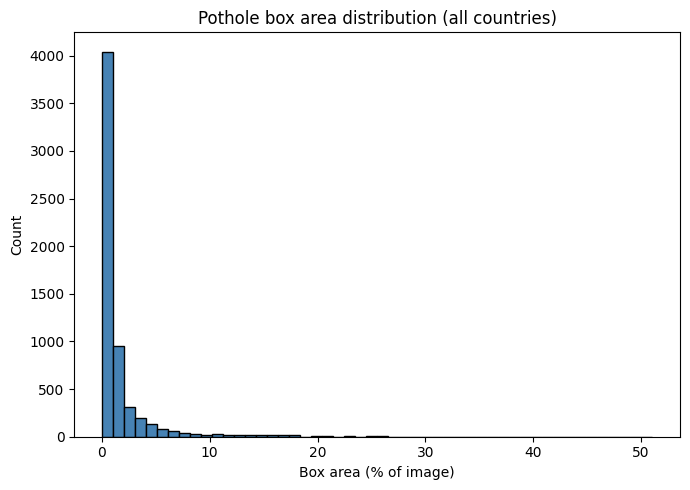

In [16]:
assess.plot_area_histogram(areas)

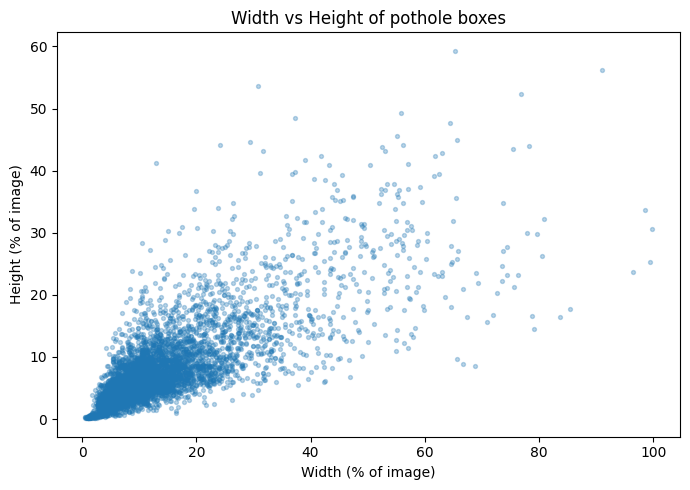

In [17]:
assess.plot_width_vs_height(widths, heights)

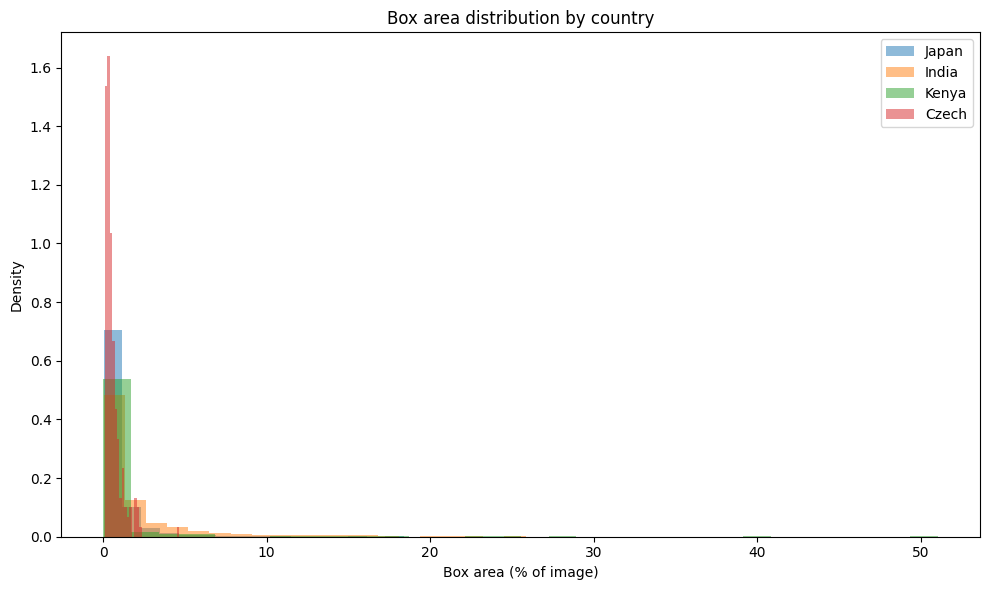

In [18]:
assess.plot_area_by_country(by_country)
#assess.check_country(FINAL_ROOT, country="kenya")

In [19]:
for split in ["train", "val"]:
    img_dir = Path(f"/content/rdd2020/final/{split}/images")
    lbl_dir = Path(f"/content/rdd2020/final/{split}/labels")

    img_stems = {f.stem for f in img_dir.glob("*")}
    lbl_stems = {f.stem for f in lbl_dir.glob("*.txt")}

    missing_labels = img_stems - lbl_stems
    orphaned_labels = lbl_stems - img_stems

    print(f"{split}: {len(img_stems)} images, {len(lbl_stems)} labels")
    print(f"  Missing labels: {len(missing_labels)}")
    print(f"  Orphaned labels: {len(orphaned_labels)}")

train: 6331 images, 6331 labels
  Missing labels: 0
  Orphaned labels: 0
val: 1589 images, 1589 labels
  Missing labels: 0
  Orphaned labels: 0


In [20]:
bad_lines = assess.is_box_or_polygon(FINAL_ROOT)

Found 0 genuinely problematic label lines


In [ ]:
overlap = assess.check_train_val_overlap(FINAL_ROOT)

Duplicate images between train and val: 0


In [ ]:
model = YOLO("yolov8s.pt")
model.train(
    data="/content/rdd2020/final/data.yaml",
    imgsz=640,
    epochs=100,
    batch=-1,
    patience=25,
    seed=42,
    name="baseline_s_640",
)

Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/rdd2020/final/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=baseline_s_640, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, ov

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x783e759617c0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
drive.mount('/content/drive')
os.makedirs("/content/drive/MyDrive/potholes/runs", exist_ok=True)

# adjust source path to match what step 1 showed you
#shutil.copytree( "/content/runs/detect/baseline_s_640/",   "/content/drive/MyDrive/potholes/runs/train_backup", dirs_exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copied to Drive


In [ ]:
!find /content/runs -name "best.pt"

/content/runs/detect/baseline_s_640/weights/best.pt


In [ ]:
results_path = "/content/runs/detect/baseline_s_640/results.csv"
df = pd.read_csv(results_path)
df.columns = df.columns.str.strip()  # Ultralytics sometimes leaves leading spaces in column names

print(df.columns.tolist())  # confirm exact column names before plotting

['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2', 'lr/pg3', 'lr/pg4', 'lr/pg5', 'lr/pg6', 'lr/pg7']


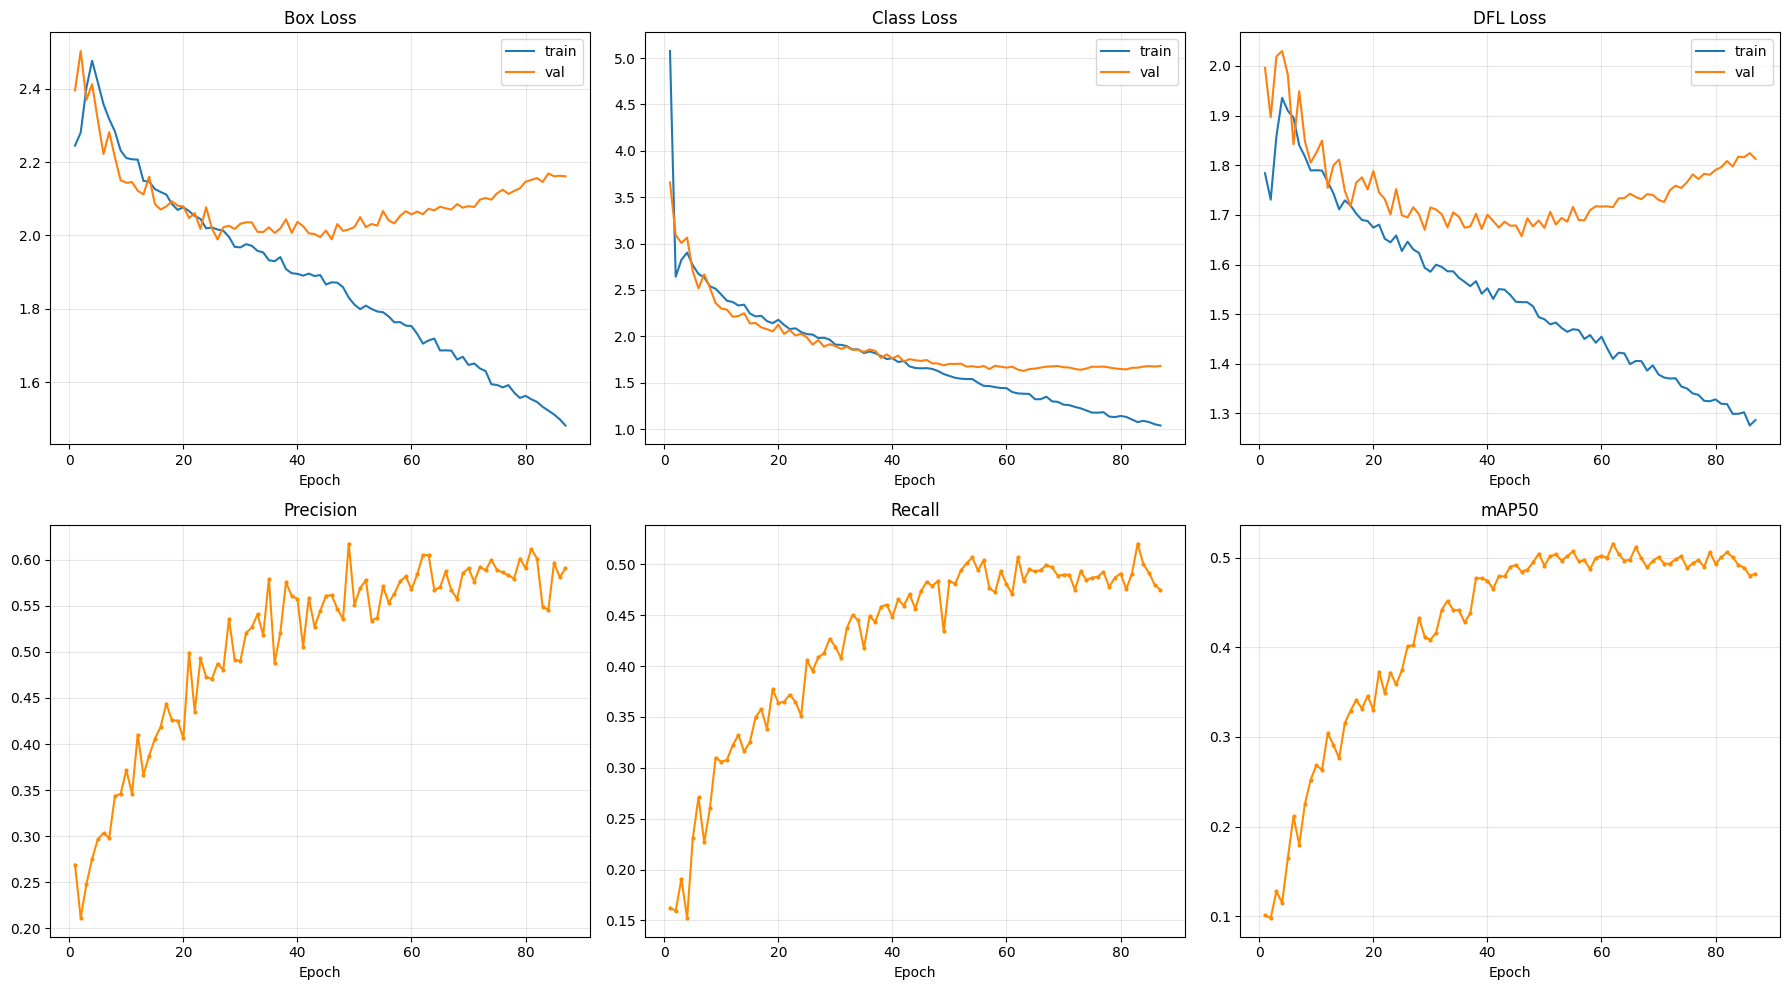

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 1: train vs val loss pairs
loss_pairs = [
    ("train/box_loss", "val/box_loss", "Box Loss"),
    ("train/cls_loss", "val/cls_loss", "Class Loss"),
    ("train/dfl_loss", "val/dfl_loss", "DFL Loss"),
]

for ax, (train_col, val_col, title) in zip(axes[0], loss_pairs):
    if train_col in df.columns and val_col in df.columns:
        ax.plot(df["epoch"], df[train_col], label="train")
        ax.plot(df["epoch"], df[val_col], label="val")
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.grid(alpha=0.3)
    else:
        ax.set_visible(False)

# Row 2: precision, recall, mAP metrics
metrics = [
    ("metrics/precision(B)", "Precision"),
    ("metrics/recall(B)", "Recall"),
    ("metrics/mAP50(B)", "mAP50"),
]

for ax, (col, title) in zip(axes[1], metrics):
    if col in df.columns:
        ax.plot(df["epoch"], df[col], color="darkorange", marker='o', markersize=2)
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.grid(alpha=0.3)
    else:
        ax.set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
model = YOLO("/content/drive/MyDrive/potholes/runs/s_960-2/weights/last.pt")
model.train(resume=True)

In [ ]:
model = YOLO("yolov8s.pt")
model.train(
    data="/content/rdd2020/final/data.yaml",
    imgsz=960,
    epochs=70,
    batch=-1,
    patience=20,
    seed=42,
    project="/content/drive/MyDrive/potholes/runs",  # saves here instead of /content/runs
    name="s_960",
)

Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/rdd2020/final/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=70, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=s_960-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_ma



---


## 6. Inference on Unseen Data

The ultimate test of an object detection model is its performance on data it has never seen before.

In this final section, we load our newly trained custom weights (`best.pt`) and run inference on the **Test** dataset. We set a confidence threshold of `0.25`, meaning the model will only draw a bounding box if it is at least 25% confident that the detected object is a pothole. Finally, we randomly sample and display the resulting images to visually verify the model's predictive accuracy.

In [ ]:


# 1. Load the newly trained custom weights
# (Using the latest_run variable from Section 5 ensures we get the right folder)
best_weights = os.path.join(results_dir, 'weights', 'best.pt')
model = YOLO(best_weights)

# 2. Define the path to the unseen test images using our dynamic variable
test_images_path = f"{dataset.location}/test/images"

# 3. Run inference!
# save=True generates the annotated images
# conf=0.25 sets the confidence threshold
print(f"Running predictions on: {test_images_path}")
results = model.predict(source=test_images_path, save=True, conf=0.25)

# 4. Display a few random predictions
# YOLO saves new predictions in a sequentially numbered 'predict' folder.
# We find the most recent one to ensure we are looking at the latest results.
predict_dirs = glob.glob('runs/detect/predict*')

if predict_dirs:
    latest_predict = max(predict_dirs, key=os.path.getmtime)
    predicted_images = glob.glob(f'{latest_predict}/*.jpg')

    if predicted_images:
        print(f"\n✅ --- Displaying Random Predictions from {latest_predict} ---")
        # Select up to 3 random images
        sample_images = random.sample(predicted_images, min(3, len(predicted_images)))
        for img_path in sample_images:
            display(Image(filename=img_path, width=800))
    else:
        print("No predicted images found inside the prediction folder.")
else:
    print("No prediction directory found. Check if model.predict() succeeded.")

Running predictions on: /content/chepalungu-1/test/images

image 1/26 /content/chepalungu-1/test/images/IMG_20241223_124318_jpg.rf.2a7165695765e7435a7d2a251f6ca041.jpg: 640x640 (no detections), 16.2ms
image 2/26 /content/chepalungu-1/test/images/IMG_20241223_124512_jpg.rf.3f09f5cf532a0931c69233607209b71a.jpg: 640x640 4 D40s, 16.2ms
image 3/26 /content/chepalungu-1/test/images/IMG_20241223_124730_jpg.rf.b6f73c67e54a4d33d39df0e232a5f95f.jpg: 640x640 1 D40, 16.2ms
image 4/26 /content/chepalungu-1/test/images/IMG_20241223_124732_jpg.rf.bfa5133b5972689508e32546759cbb22.jpg: 640x640 (no detections), 16.1ms
image 5/26 /content/chepalungu-1/test/images/IMG_20241223_124734_jpg.rf.f45e3c80d9a8513fd6edb1d4bf7d1b9b.jpg: 640x640 2 D40s, 16.1ms
image 6/26 /content/chepalungu-1/test/images/IMG_20241223_124927_jpg.rf.7533d31f3e831d06fd9b2dbae8b18e91.jpg: 640x640 1 D40, 16.2ms
image 7/26 /content/chepalungu-1/test/images/IMG_20241223_124953_jpg.rf.7a60a53cb3a4529454b9da650e7489bd.jpg: 640x640 (no detec

NameError: name 'glob' is not defined